In [16]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from PIL import Image, ImageOps, ImageFilter
import numpy as np
import os
from PIL import ImageOps, ImageFilter


print("Baixando dados...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist.data, mnist.target

X = X[:25000]
y = y[:25000]

Baixando dados...


In [17]:
# Data augmentation + leitura de fotos rotuladas (0-9)
from pathlib import Path
import random
from PIL import ImageEnhance, ImageFilter

def preprocessar_imagem(
    caminho_arquivo,
    aplicar_inversao=True,
    auto_invert=True,
    usar_autocontrast=False,
    usar_filtro=True,
    limiar=30,
    tamanho_alvo=28,
    tamanho_digito=20,
    ):
    img = Image.open(caminho_arquivo).convert('L')
    img_original = img.copy()

    if usar_autocontrast:
        img = ImageOps.autocontrast(img)

    if auto_invert:
        if np.array(img).mean() > 127:
            img = ImageOps.invert(img)
    elif aplicar_inversao:
        img = ImageOps.invert(img)

    if usar_filtro:
        img = img.filter(ImageFilter.MedianFilter(size=3))

    arr = np.array(img)
    ys, xs = np.where(arr > limiar)
    if len(xs) > 0 and len(ys) > 0:
        bbox = (xs.min(), ys.min(), xs.max() + 1, ys.max() + 1)
        img = img.crop(bbox)

    w, h = img.size
    escala = float(tamanho_digito) / max(w, h)
    novo_w, novo_h = max(1, int(w * escala)), max(1, int(h * escala))
    img = img.resize((novo_w, novo_h), Image.LANCZOS)
    canvas = Image.new('L', (tamanho_alvo, tamanho_alvo), 0)
    offset = ((tamanho_alvo - novo_w) // 2, (tamanho_alvo - novo_h) // 2)
    canvas.paste(img, offset)
    return img_original, canvas

def aplicar_shift(img_proc, dx, dy):
    return (
        ImageOps.expand(img_proc, border=2, fill=0)
        .crop((2 + dx, 2 + dy, 30 + dx, 30 + dy))
    )

def gerar_variantes(
    img_proc,
    n_augment=8,
    rot_range=12,
    shift=2,
    contrast_range=(0.8, 1.2),
    thickness_modes=("orig", "thick", "thin"),
    ):
    variantes = []
    for _ in range(n_augment):
        img = img_proc
        ang = random.uniform(-rot_range, rot_range)
        img = img.rotate(ang, fillcolor=0)
        dx = random.randint(-shift, shift)
        dy = random.randint(-shift, shift)
        img = aplicar_shift(img, dx, dy)
        mode = random.choice(thickness_modes)
        if mode == "thick":
            img = img.filter(ImageFilter.MaxFilter(size=3))
        elif mode == "thin":
            img = img.filter(ImageFilter.MinFilter(size=3))
        c = random.uniform(*contrast_range)
        img = ImageEnhance.Contrast(img).enhance(c)
        variantes.append(img)
    return variantes

def carregar_dataset_personalizado(
    root_dir,
    max_por_classe=None,
    augmentar=True,
    n_augment=8,
    incluir_original=True,
    seed=42,
    ):
    X_list, y_list = [], []
    root = Path(root_dir)
    if seed is not None:
        random.seed(seed)
    subdirs = sorted([p for p in root.iterdir() if p.is_dir()])
    print(f"Pastas encontradas: {[p.name for p in subdirs]}")
    for classe_dir in subdirs:
        label = classe_dir.name
        arquivos = list(classe_dir.glob("*"))
        print(f"  Classe '{label}': {len(arquivos)} arquivos")
        if max_por_classe:
            random.shuffle(arquivos)
            arquivos = arquivos[:max_por_classe]
        erros = 0
        for caminho in arquivos:
            try:
                _, img_proc = preprocessar_imagem(str(caminho))
            except Exception as e:
                erros += 1
                if erros <= 2:
                    print(f"    ERRO em {caminho.name}: {e}")
                continue
            imgs = []
            if incluir_original:
                imgs.append(img_proc)
            if augmentar:
                imgs = imgs + gerar_variantes(img_proc, n_augment=n_augment)
            for img in imgs:
                X_list.append(np.array(img).reshape(-1))
                y_list.append(label)
        ok = len(arquivos) - erros
        print(f"    -> {ok} carregadas, {erros} erros")
    return np.array(X_list), np.array(y_list)


In [18]:
from sklearn.pipeline import Pipeline

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Treinando o modelo...")
log_clf = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=1000))
    ]
 )
rf_clf = RandomForestClassifier(n_estimators=200, random_state=42)
svm_clf = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(gamma='scale'))
    ]
 )

voting_clf = VotingClassifier(
    estimators=[('lr', log_clf), ('rf', rf_clf), ('svc', svm_clf)],
    voting='hard'
    )

voting_clf.fit(X_train, y_train)


Treinando o modelo...


,estimators,"[('lr', ...), ('rf', ...), ...]"
,voting,'hard'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False


In [ ]:
# Carregar fotos personalizadas e retreinar misturando com MNIST
custom_root = "/home/raf75/sexto-periodo/machine/fotos"
X_custom, y_custom = carregar_dataset_personalizado(
    custom_root,
    max_por_classe=200,
    augmentar=True,
    n_augment=6,
)
print(X_custom.shape, y_custom.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)##X eh o estudo e y eh o teste

print("Treinando o modelo...")
log_clf = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=1000))
    ]
 )
rf_clf = RandomForestClassifier(n_estimators=200, random_state=42)
svm_clf = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(gamma='scale'))
    ]
 )

voting_clf = VotingClassifier( ##combinacao de 3 algoritmos para funcionar melhor
    estimators=[('lr', log_clf), ('rf', rf_clf), ('svc', svm_clf)],
    voting='hard'
    )

voting_clf.fit(X_train, y_train)

Pastas encontradas: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
  Classe '0': 17 arquivos
    -> 17 carregadas, 0 erros
  Classe '1': 6 arquivos
    -> 6 carregadas, 0 erros
  Classe '2': 20 arquivos
    -> 20 carregadas, 0 erros
  Classe '3': 15 arquivos
    -> 15 carregadas, 0 erros
  Classe '4': 8 arquivos
    -> 8 carregadas, 0 erros
  Classe '5': 10 arquivos
    -> 10 carregadas, 0 erros
  Classe '6': 6 arquivos
    -> 6 carregadas, 0 erros
  Classe '7': 17 arquivos
    -> 17 carregadas, 0 erros
  Classe '8': 9 arquivos
    -> 9 carregadas, 0 erros
  Classe '9': 9 arquivos
    -> 9 carregadas, 0 erros
(819, 784) (819,)
Treinando o modelo...



Resultado da predicao: 3
Media original: 236.34 | Media processada: 26.19


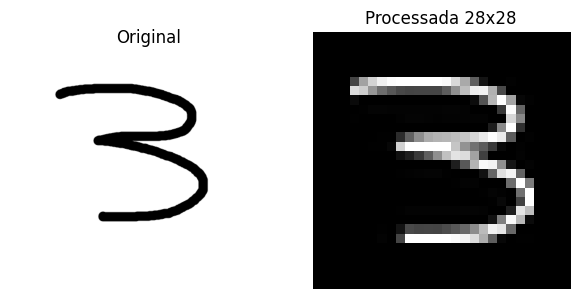

In [34]:
import matplotlib.pyplot as plt
from PIL import Image, ImageOps, ImageFilter

def preprocessar_imagem(
    caminho_arquivo,
    aplicar_inversao=True,
    auto_invert=True,
    usar_autocontrast=False,
    usar_filtro=True,
    limiar=30,
    tamanho_alvo=28,
    tamanho_digito=20,
    ):
    img = Image.open(caminho_arquivo).convert('L')
    img_original = img.copy()
    
    if usar_autocontrast:
        img = ImageOps.autocontrast(img)
    
    if auto_invert:
        if np.array(img).mean() > 127:
            img = ImageOps.invert(img)
    elif aplicar_inversao:
        img = ImageOps.invert(img)
    
    if usar_filtro:
        img = img.filter(ImageFilter.MedianFilter(size=3))
    
    arr = np.array(img)
    ys, xs = np.where(arr > limiar)
    if len(xs) > 0 and len(ys) > 0:
        bbox = (xs.min(), ys.min(), xs.max() + 1, ys.max() + 1)
        img = img.crop(bbox)
    
    w, h = img.size
    escala = float(tamanho_digito) / max(w, h)
    novo_w, novo_h = max(1, int(w * escala)), max(1, int(h * escala))
    img = img.resize((novo_w, novo_h), Image.LANCZOS)
    canvas = Image.new('L', (tamanho_alvo, tamanho_alvo), 0)
    offset = ((tamanho_alvo - novo_w) // 2, (tamanho_alvo - novo_h) // 2)
    canvas.paste(img, offset)
    return img_original, canvas

def prever_digito(caminho_arquivo, modelo, aplicar_inversao=True):
    img_original, img_proc = preprocessar_imagem(
        caminho_arquivo,
        aplicar_inversao=aplicar_inversao,
        auto_invert=True,
        usar_autocontrast=False,
        usar_filtro=True,
        limiar=30,
    )
    img_array = np.array(img_proc).reshape(1, -1)
    return modelo.predict(img_array)[0], img_original, img_proc

diretorio = '/home/raf75/sexto-periodo/machine/fotos'
nome_arquivo = 'teste_3.png'
caminho_completo = os.path.join(diretorio, nome_arquivo)

aplicar_inversao = True

try:
    resultado, img_orig, img_proc = prever_digito(
        caminho_completo,
        voting_clf,
        aplicar_inversao=aplicar_inversao,
    )
    print(f"\nResultado da predicao: {resultado}")
    print(f"Media original: {np.array(img_orig).mean():.2f} | Media processada: {np.array(img_proc).mean():.2f}")
    
    plt.figure(figsize=(6, 3))
    plt.subplot(1, 2, 1)
    plt.title('Original')
    plt.imshow(img_orig, cmap='gray')
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.title('Processada 28x28')
    plt.imshow(img_proc, cmap='gray')
    plt.axis('off')
    plt.tight_layout()
    plt.show()
except FileNotFoundError:
    print(f"\nErro: O arquivo {caminho_completo} nao foi encontrado.")